In [1]:
import sys
from pathlib import Path
import numpy as np, pandas as pd, duckdb

def _root():
    p = Path.cwd().resolve()
    for d in (p, *p.parents):
        if (d/"config.py").exists() and (d/"src").is_dir(): return d
    raise RuntimeError("root not found")
ROOT=_root(); sys.path.insert(0,str(ROOT))
from src.evaluation.calibrator import IsotonicCalibrator

DB = ROOT/"data"/"market_data.duckdb"
MV = "m01_binary_20260524_222020"        # the deployed binary champion version
cal = IsotonicCalibrator.load(ROOT/"models"/"m01_binary"/"v1"/"calibrator.joblib")

con = duckdb.connect(str(DB), read_only=True)   # read_only — never lock the DB
b = con.execute(f"""
  SELECT prediction_date, ticker, cohort, prob_class_1 AS p_pos, rank_within_day
  FROM daily_predictions WHERE model_version_id='{MV}'
""").df()
con.close()
b["prediction_date"] = pd.to_datetime(b["prediction_date"])
b["p_cal"] = cal.transform(b["p_pos"].values)   # what the BACKTEST ranks on
print(f"{len(b)} rows, {b.prediction_date.nunique()} days, cohorts={b.cohort.unique().tolist()}")
print(f"raw p_pos distinct={b.p_pos.nunique()}  ->  calibrated distinct={b.p_cal.nunique()}   (flattening)")


2039 rows, 169 days, cohorts=['breakout']
raw p_pos distinct=2038  ->  calibrated distinct=23   (flattening)


In [2]:
grid = np.linspace(0.001, 0.999, 1000)
cg = cal.transform(grid)
gate_raw = grid[np.searchsorted(cg, 0.15)]
print(f"gate cal=0.15  ==  raw p_pos >= {gate_raw:.3f}   (i.e. the model's ~50/50 line)")
print(f"calibrator maps 1000 raw values -> {len(np.unique(np.round(cg,6)))} distinct plateaus")
# spread erased around the gate: two very different raw probs -> same calibrated value
for r in (0.20, 0.30, 0.40, 0.50, 0.60):
    print(f"  raw {r:.2f} -> cal {cal.transform(np.array([r]))[0]:.4f}")

gate cal=0.15  ==  raw p_pos >= 0.483   (i.e. the model's ~50/50 line)
calibrator maps 1000 raw values -> 66 distinct plateaus
  raw 0.20 -> cal 0.0542
  raw 0.30 -> cal 0.0542
  raw 0.40 -> cal 0.0920
  raw 0.50 -> cal 0.1500
  raw 0.60 -> cal 0.1905


In [3]:
per_pre  = b.groupby("prediction_date").size()
adm = b[b.p_cal >= 0.15]
per_gate = adm.groupby("prediction_date").size()
print(f"breakout cohort / day  : med {per_pre.median():.0f}  p10 {per_pre.quantile(.1):.0f}  p90 {per_pre.quantile(.9):.0f}")
print(f"after 0.15 gate  / day : med {per_gate.median():.0f}  p10 {per_gate.quantile(.1):.0f}  p90 {per_gate.quantile(.9):.0f}  max {per_gate.max()}")
print(f"gate admits {(b.p_cal>=0.15).mean():.1%} of the breakout cohort")


breakout cohort / day  : med 10  p10 3  p90 22
after 0.15 gate  / day : med 6  p10 2  p90 12  max 32
gate admits 55.6% of the breakout cohort


In [4]:
H = 20
con = duckdb.connect(str(DB), read_only=True)
tk = tuple(sorted(b.ticker.unique()))
lo = (b.prediction_date.min()-pd.Timedelta(days=5)).strftime("%Y-%m-%d")
hi = (b.prediction_date.max()+pd.Timedelta(days=H*3+10)).strftime("%Y-%m-%d")
px = con.execute(f"SELECT ticker,date,close FROM price_data WHERE ticker IN {tk} AND date BETWEEN ? AND ? ORDER BY ticker,date",[lo,hi]).df()
con.close()
px["date"]=pd.to_datetime(px["date"])
pxg = {t:g.set_index("date")["close"] for t,g in px.groupby("ticker")}
def fwd(r):
    s = pxg.get(r["ticker"])
    if s is None: return np.nan
    s = s[s.index>=r["prediction_date"]]
    if len(s)<=H or s.iloc[0]==0: return np.nan
    return s.iloc[H]/s.iloc[0]-1
b["fwd20"] = b.apply(fwd, axis=1)
sc = b.dropna(subset=["fwd20"]).copy()
print(f"scored {len(sc)} rows for 20d fwd return")

scored 1896 rows for 20d fwd return


In [5]:
from scipy.stats import spearmanr
for col in ("p_pos", "p_cal"):
    sc["dec"] = pd.qcut(sc[col], 10, labels=False, duplicates="drop")
    g = sc.groupby("dec")["fwd20"].mean()
    rho = spearmanr(g.index, g.values).correlation
    print(f"[{col}] top-dec {g.iloc[-1]*100:+.1f}%  bot-dec {g.iloc[0]*100:+.1f}%  "
          f"spread {(g.iloc[-1]-g.iloc[0])*100:+.1f}%  monotonic rho {rho:+.2f}")
# EXPECT: p_pos weakly positive+monotonic (rho~0.6); p_cal top decile NEGATIVE (calibration
# inverts the sharp end) -> ranking on calibrated prob_elite is actively harmful for top-5.

[p_pos] top-dec +1.6%  bot-dec +1.4%  spread +0.2%  monotonic rho +0.60
[p_cal] top-dec -1.6%  bot-dec +1.2%  spread -2.9%  monotonic rho +0.20


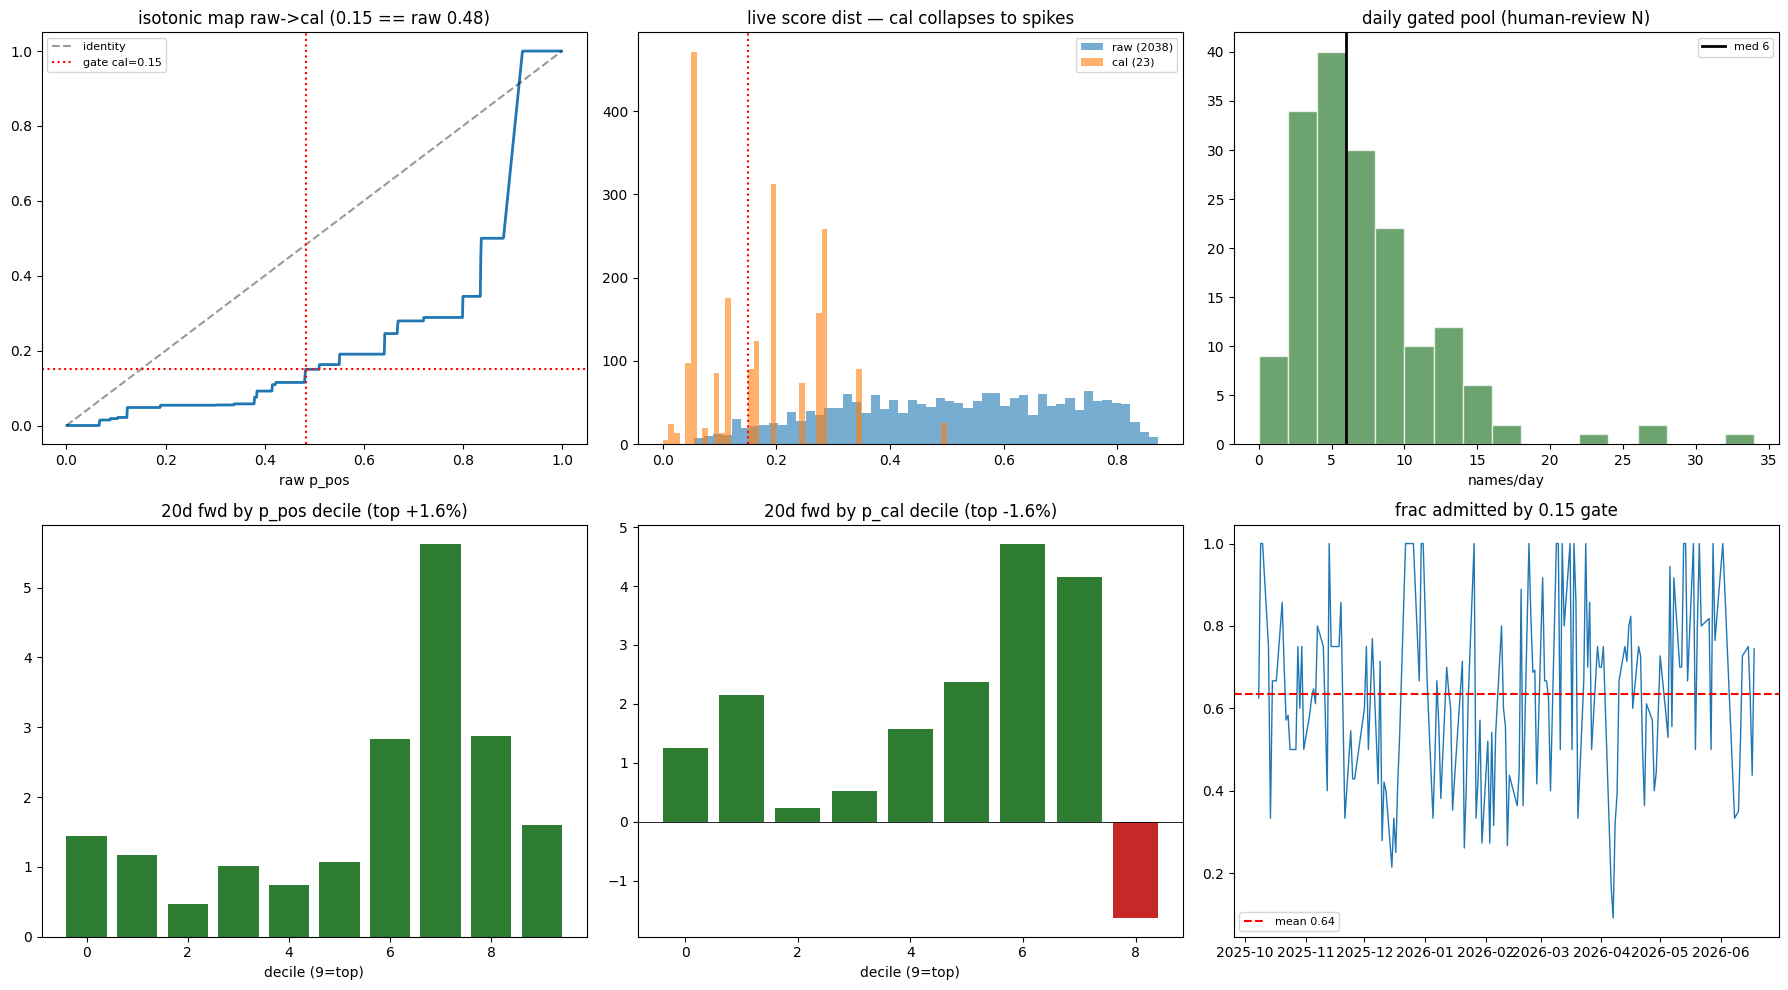

In [6]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(2, 3, figsize=(18, 10))
# 1 calibration map
ax[0,0].plot(grid, cg, lw=2); ax[0,0].plot([0,1],[0,1],"k--",alpha=.4,label="identity")
ax[0,0].axhline(0.15,color="r",ls=":",label="gate cal=0.15"); ax[0,0].axvline(gate_raw,color="r",ls=":")
ax[0,0].set_title("isotonic map raw->cal (0.15 == raw %.2f)"%gate_raw); ax[0,0].set_xlabel("raw p_pos"); ax[0,0].legend(fontsize=8)
# 2 dist raw vs cal
ax[0,1].hist(b.p_pos,bins=50,alpha=.6,label=f"raw ({b.p_pos.nunique()})")
ax[0,1].hist(b.p_cal,bins=50,alpha=.6,label=f"cal ({b.p_cal.nunique()})")
ax[0,1].axvline(0.15,color="r",ls=":"); ax[0,1].set_title("live score dist — cal collapses to spikes"); ax[0,1].legend(fontsize=8)
# 3 pool size
ax[0,2].hist(per_gate,bins=range(0,35,2),color="#2e7d32",alpha=.7,edgecolor="w")
ax[0,2].axvline(per_gate.median(),color="k",lw=2,label=f"med {per_gate.median():.0f}")
ax[0,2].set_title("daily gated pool (human-review N)"); ax[0,2].set_xlabel("names/day"); ax[0,2].legend(fontsize=8)
# 4,5 decile fwd
for j,col in enumerate(("p_pos","p_cal")):
    sc["dec"]=pd.qcut(sc[col],10,labels=False,duplicates="drop"); g=sc.groupby("dec")["fwd20"].mean()
    ax[1,j].bar(g.index,g.values*100,color=np.where(g>0,"#2e7d32","#c62828")); ax[1,j].axhline(0,color="k",lw=.6)
    ax[1,j].set_title(f"20d fwd by {col} decile (top {g.iloc[-1]*100:+.1f}%)"); ax[1,j].set_xlabel("decile (9=top)")
# 6 gate admission over time
af=b.assign(g=b.p_cal>=0.15).groupby("prediction_date")["g"].mean()
ax[1,2].plot(af.index,af.values,lw=1); ax[1,2].axhline(af.mean(),color="r",ls="--",label=f"mean {af.mean():.2f}")
ax[1,2].set_title("frac admitted by 0.15 gate"); ax[1,2].legend(fontsize=8)
plt.tight_layout(); plt.show()

### Read

- **The champion is the BINARY model** (`m01_binary/v1`), scored `prob_class_1` = P(positive) —
  NOT the 4-class P(>30%). The two scores are on different, non-comparable scales.
- **0.15 is not a low gate — it's raw `p_pos ≥ 0.48`** (the model's ~50/50 line). It looked low
  only because we were comparing it to the *4-class* P(HomeRun) (median ~0.31). The isotonic
  calibrator maps raw 0.50 → 0.15 because the model is overconfident (raw 50% ≈ 15% realized).
- **Human-review population is small: ~6 names/day after the gate** (~10 pre-gate). This is the
  Minervini-style shortlist size for the breakout cohort. (Pre-breakout's 338/day is the 4-class
  funnel — a different, wider list.)
- **CALIBRATED RANKING IS HARMFUL AT THE TOP.** The calibrated top decile has the *worst* 20d fwd
  return (negative); raw `p_pos` is weakly positive + monotonic (rho ~0.6). The champion ranks
  top-5 on the calibrated score → it's picking from a mis-ordered top. This corroborates the
  existing `models/m01_binary/v1/backtests/` evidence (raw Sharpe 1.44 vs calibrated 0.78).
- **Implication:** the sprint-13 "gate-not-ranker → widen the basket" plan is premature. The
  lazy fix is **rank on raw `p_pos`, not calibrated `prob_elite`** — the calibrator should be
  used for *display probabilities*, never as the *ranking key*. Confirm via the corrected
  cohort-bootstrap (Phase 0) then a WFO re-run with `rank_by` on raw prob.
- **Caveat:** raw `p_pos`'s edge is weak (top-vs-bottom decile spread only ~+0.2%/20d). It's a
  better ranker than calibrated, but not a strong one. Widening the basket stays a live option B.

In [7]:
df = pd.read_parquet(ROOT/"data"/"model_output_eda"/"raw_full_2025_fwd.parquet").dropna(subset=["fwd20"])
s, f, N = df["prob_elite"].values, df["fwd20"].values, len(df)   # prob_elite col == RAW p_pos here (naming trap)
GATE, HR = 0.48, 0.30                                            # 0.48 = calibrated 0.15

def excess(x): return np.maximum(x - HR, 0.0)                    # tail magnitude above the 30% line
assert abs(excess(np.array([0.35]))[0] - 0.05) < 1e-9 and (excess(f) >= 0).all()

tail = excess(f); tot_tail = tail.sum(); above = s >= GATE
print(f"{N} rows | home-run events (>30%) = {(f>HR).sum()} ({(f>HR).mean():.2%}) | total tail = {tot_tail:.1f}")
print(f"max fwd20 = {f.max():+.1%}  (this is what the binary count erases)")

596429 rows | home-run events (>30%) = 19431 (3.26%) | total tail = 3922.1
max fwd20 = +545.2%  (this is what the binary count erases)


In [8]:
miss_c = (f[~above] > HR).sum() / (f > HR).sum()
miss_t = tail[~above].sum() / tot_tail
print(f"{'metric':<30}{'miss %':>9}")
print(f"{'home-run COUNT (old binary)':<30}{miss_c:>8.1%}")
print(f"{'tail MAGNITUDE Σmax(fwd-30%,0)':<30}{miss_t:>8.1%}")
print(f"\nmedian magnitude — captured HR {np.median(f[above&(f>HR)]):+.1%}  vs  missed HR {np.median(f[~above&(f>HR)]):+.1%}")
print(f"mean excess     — captured HR {excess(f[above&(f>HR)]).mean():.3f}   vs  missed HR {excess(f[~above&(f>HR)]).mean():.3f}")
# READ: 14.2% of tail missed, not 23.4% of events. Missed home-runs are the SMALL ones -> gate keeps the big tail.


metric                           miss %
home-run COUNT (old binary)      23.4%
tail MAGNITUDE Σmax(fwd-30%,0)   14.2%

median magnitude — captured HR +42.6%  vs  missed HR +37.3%
mean excess     — captured HR 0.226   vs  missed HR 0.122


In [9]:
top1 = f >= np.quantile(f, 0.99)
pctile = pd.Series(s).rank(pct=True).values
print(f"top-1% fwd ({top1.sum()} events, cutoff {np.quantile(f,0.99):+.1%}):")
print(f"  median score-percentile {np.median(pctile[top1]):.3f}   mean {np.mean(pctile[top1]):.3f}   (0.5 = no signal)")
print(f"  frac clearing the {GATE} gate: {above[top1].mean():.1%}  (vs base {above.mean():.1%})\n")

order = np.argsort(-s); cum = np.cumsum(tail[order]) / tot_tail   # walk score top-down
print("tail-lift@k (share of total tail in top-k scores / k):")
for frac in (0.01, 0.05, 0.10, 0.25, 0.50):
    i = int(frac*N)-1
    print(f"  top {frac:>4.0%}  ->  {cum[i]:>5.1%} of tail   lift {cum[i]/frac:.2f}x")
# READ: top-1% of scores hold 6.1x their share of the tail. The score ranks the tail on the FULL universe.

top-1% fwd (5965 events, cutoff +49.9%):
  median score-percentile 0.891   mean 0.835   (0.5 = no signal)
  frac clearing the 0.48 gate: 86.3%  (vs base 33.7%)

tail-lift@k (share of total tail in top-k scores / k):
  top   1%  ->   6.1% of tail   lift 6.12x
  top   5%  ->  25.1% of tail   lift 5.01x
  top  10%  ->  46.7% of tail   lift 4.67x
  top  25%  ->  77.2% of tail   lift 3.09x
  top  50%  ->  94.4% of tail   lift 1.89x


In [10]:
df2 = df.assign(tail=tail, ventile=pd.qcut(df["prob_elite"], 20, labels=False, duplicates="drop"))
g = df2.groupby("ventile").agg(hr_rate=("fwd20", lambda x:(x>HR).mean()), mean_tail=("tail","mean"),
                               sum_tail=("tail","sum"))
g["tail_share"] = g["sum_tail"]/tot_tail
print(g.loc[[0,9,14,17,18,19], ["hr_rate","mean_tail","tail_share"]].to_string())
print(f"\nmonotonic rho — HR-rate {spearmanr(g.index,g.hr_rate).correlation:+.2f}   "
      f"mean-tail {spearmanr(g.index,g.mean_tail).correlation:+.2f}")
# READ: both grade monotonically (rho +1.00); top ventile alone holds ~25% of ALL tail magnitude.

          hr_rate  mean_tail  tail_share
ventile                                 
0        0.000469   0.000062    0.000472
9        0.014888   0.001866    0.014186
14       0.043491   0.006819    0.051847
17       0.076353   0.018209    0.138451
18       0.107475   0.028497    0.216667
19       0.127222   0.032948    0.250522

monotonic rho — HR-rate +1.00   mean-tail +1.00


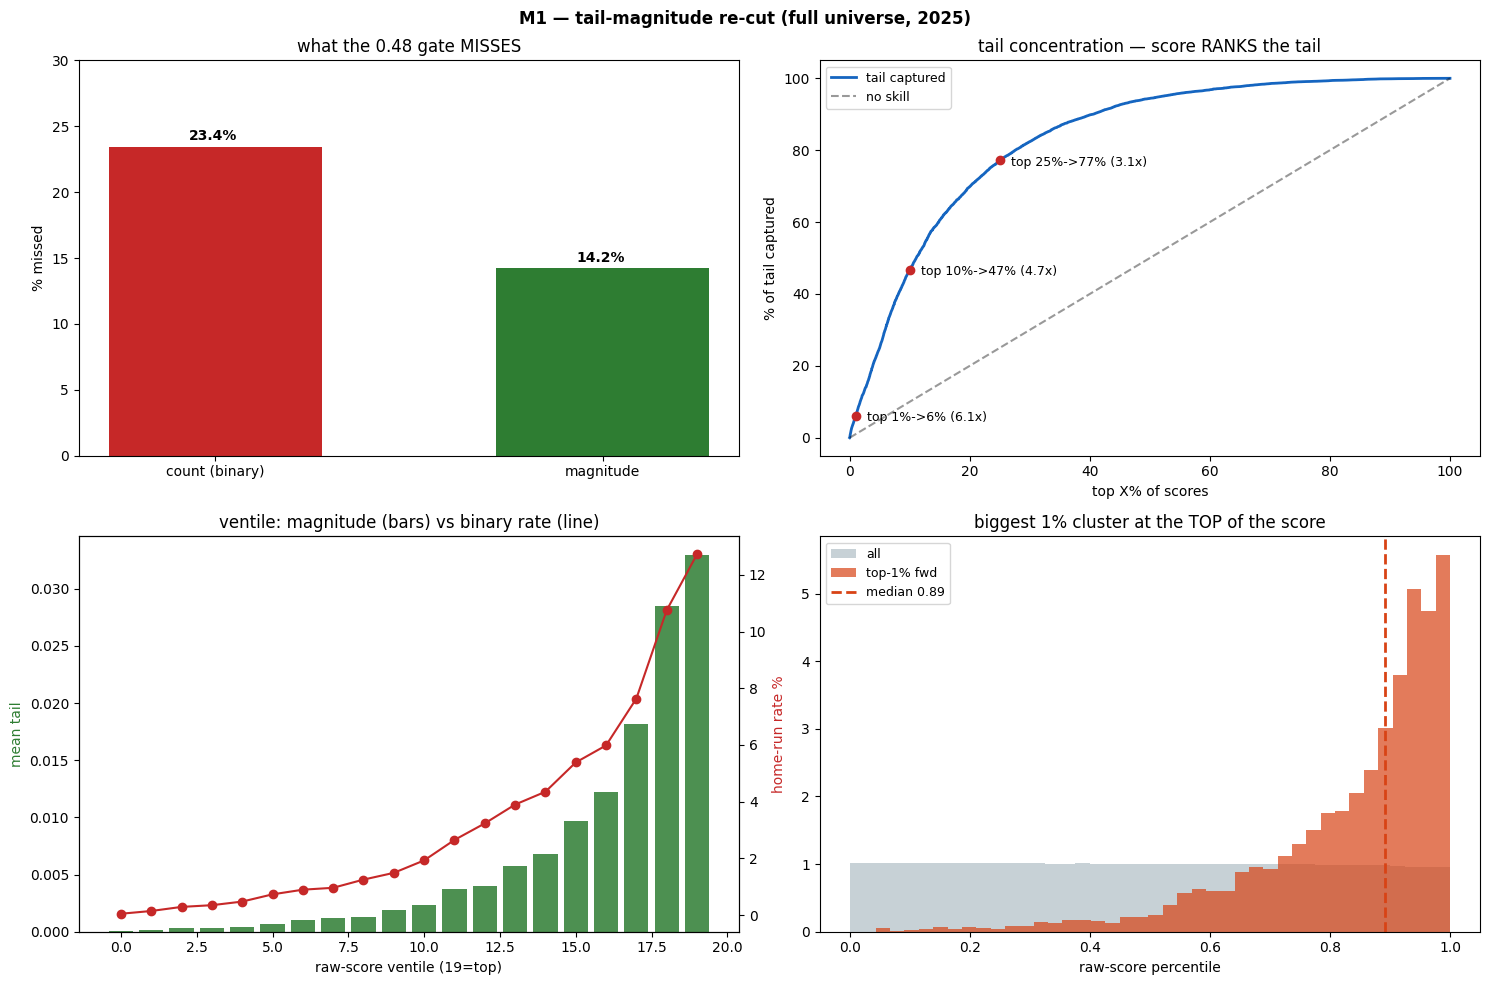

In [11]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(2, 2, figsize=(15, 10))

# 1 binary-miss vs magnitude-miss
b = ax[0,0].bar(["count (binary)","magnitude"], [miss_c*100, miss_t*100], color=["#c62828","#2e7d32"], width=.55)
for r,v in zip(b,[miss_c,miss_t]): ax[0,0].text(r.get_x()+.27, v*100+.5, f"{v:.1%}", ha="center", weight="bold")
ax[0,0].set_title(f"what the {GATE} gate MISSES"); ax[0,0].set_ylabel("% missed"); ax[0,0].set_ylim(0,30)

# 2 tail-capture concentration
ax[0,1].plot(np.arange(1,N+1)/N*100, cum*100, lw=2, color="#1565c0", label="tail captured")
ax[0,1].plot([0,100],[0,100],"k--",alpha=.4,label="no skill")
for fr in (0.01,0.10,0.25):
    i=int(fr*N)-1; ax[0,1].plot(fr*100,cum[i]*100,"o",color="#c62828")
    ax[0,1].annotate(f"top {fr:.0%}->{cum[i]:.0%} ({cum[i]/fr:.1f}x)",(fr*100,cum[i]*100),
                     textcoords="offset points",xytext=(8,-4),fontsize=9)
ax[0,1].set_title("tail concentration — score RANKS the tail"); ax[0,1].set_xlabel("top X% of scores")
ax[0,1].set_ylabel("% of tail captured"); ax[0,1].legend(fontsize=9)

# 3 ventile magnitude (bars) vs binary rate (line)
axb=ax[1,0]; axb.bar(g.index,g.mean_tail,color="#2e7d32",alpha=.85); axb.set_ylabel("mean tail",color="#2e7d32")
axt=axb.twinx(); axt.plot(g.index,g.hr_rate*100,"o-",color="#c62828"); axt.set_ylabel("home-run rate %",color="#c62828")
axb.set_title("ventile: magnitude (bars) vs binary rate (line)"); axb.set_xlabel("raw-score ventile (19=top)")

# 4 where the top-1% fwd sit in the score dist
ax[1,1].hist(pctile[~top1],bins=40,alpha=.5,density=True,color="#90a4ae",label="all")
ax[1,1].hist(pctile[top1],bins=40,alpha=.7,density=True,color="#d84315",label="top-1% fwd")
ax[1,1].axvline(np.median(pctile[top1]),color="#d84315",ls="--",lw=2,label=f"median {np.median(pctile[top1]):.2f}")
ax[1,1].set_title("biggest 1% cluster at the TOP of the score"); ax[1,1].set_xlabel("raw-score percentile")
ax[1,1].legend(fontsize=9)

fig.suptitle("M1 — tail-magnitude re-cut (full universe, 2025)", weight="bold")
plt.tight_layout(); plt.show()